In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast

# 데이터 불러오기
original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
21_40주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-268.355, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-270.545, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-271.940, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-270.783, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-272.535, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-272.149, Time=0.07 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.338 seconds

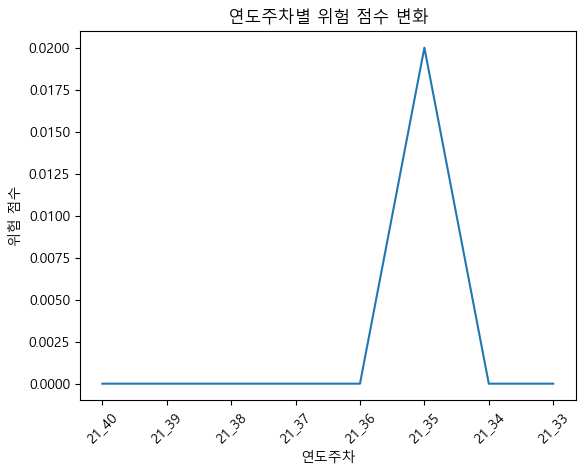

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
19_30주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=436.968, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=427.146, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=429.875, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=429.125, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=429.136, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=430.950, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept

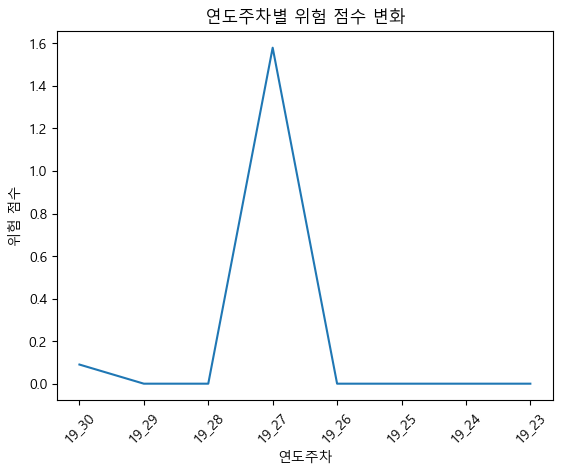

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
21_14주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-155.152, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-129.423, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-153.942, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-148.322, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-152.106, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-150.332, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-153.161, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[0]           

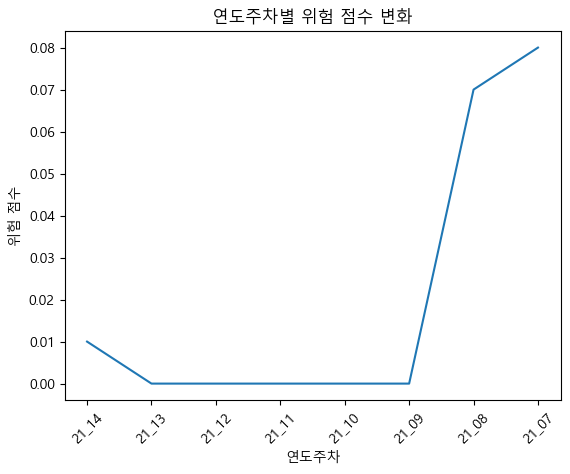

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
21_45주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-13.663, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-18.317, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-16.978, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-17.046, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-19.967, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-15.055, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.278 seconds
=================

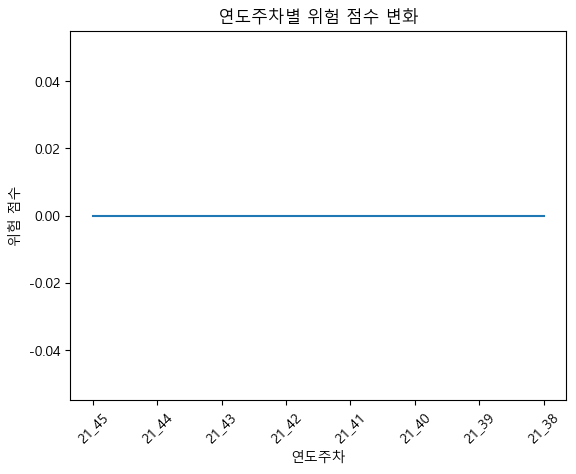

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
21_51주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-302.892, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-191.421, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-299.582, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-241.546, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-303.364, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-272.007, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-304.524, Time=0.01 se

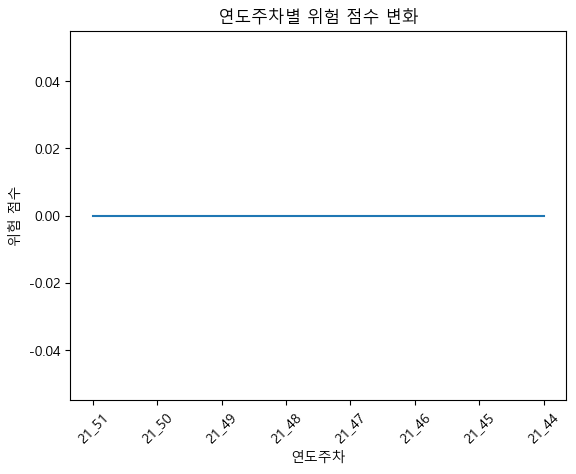

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
21_51주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=75.015, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-62.259, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-62.839, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-63.249, Time=0.06 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-61.253, Time=0.08 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-61.250,

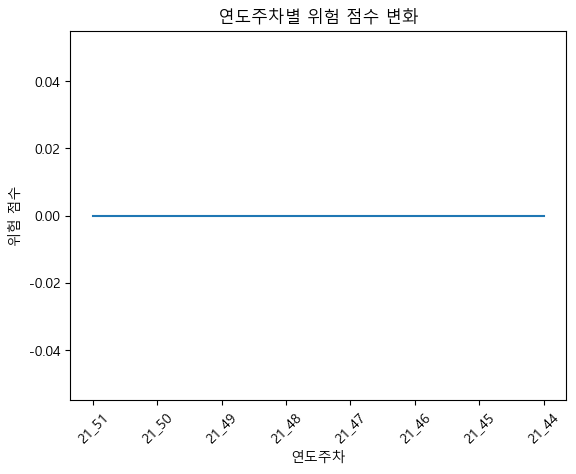

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_02주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-227.357, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-206.907, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-228.621, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-219.000, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-227.873, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-227.343, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-227.268, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0

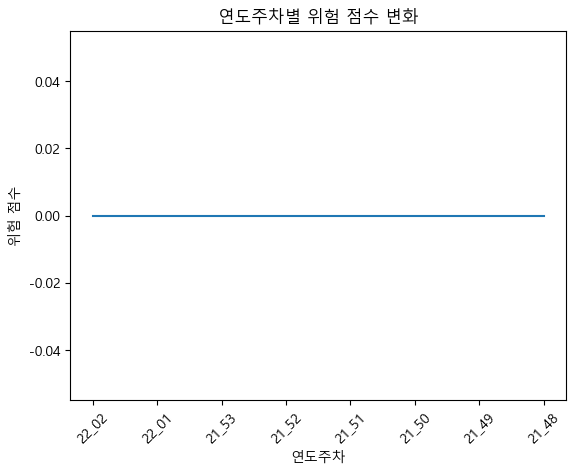

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-29.343, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=19.964, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-24.898, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-12.115, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-29.342, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-28.146, Time=0.15 sec
 ARIMA(2,0,3)(0,0,0)[0]            

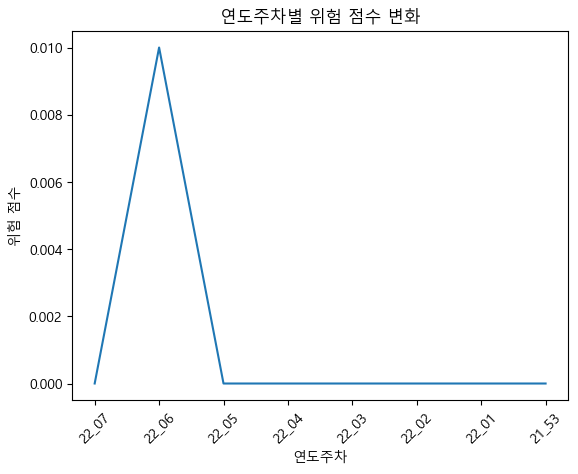

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_08주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-43.204, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=70.368, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-32.370, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=20.691, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-44.785, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-13.570, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-40.020, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]         

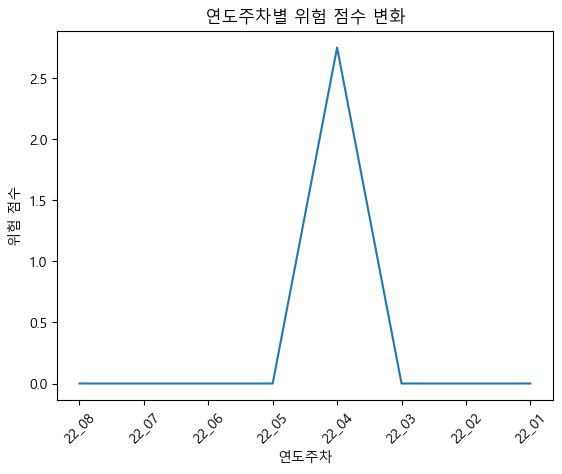

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-201.308, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-206.330, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-204.462, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-204.445, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-207.658, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-202.422, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.363 seconds
===========

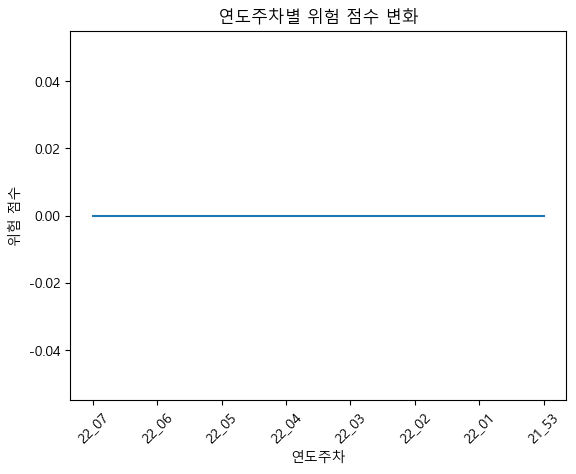

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-315.880, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-281.181, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-319.388, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-310.113, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-317.396, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-317.395, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-317.322, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0

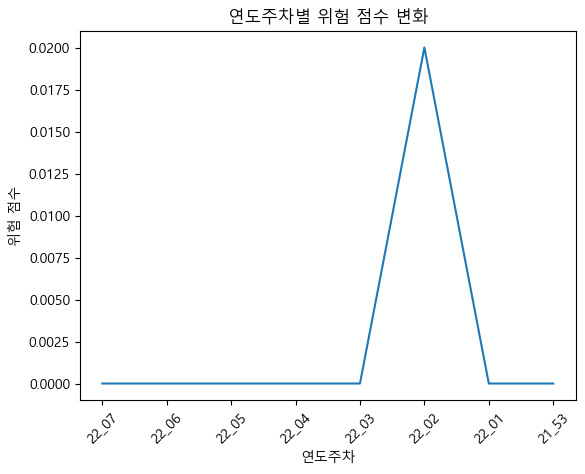

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=77.591, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=86.204, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=76.604, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=73.380, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=75.183, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=75.128, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=76.769, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=74.528

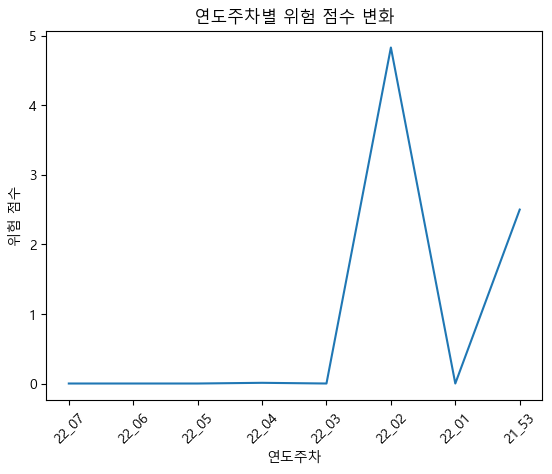

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=102.542, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=129.961, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=106.717, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=114.000, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=100.667, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=98.669, Time=0.02 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=100.667, Time=0.05 sec
 ARIMA(1,0,1)(0,0,

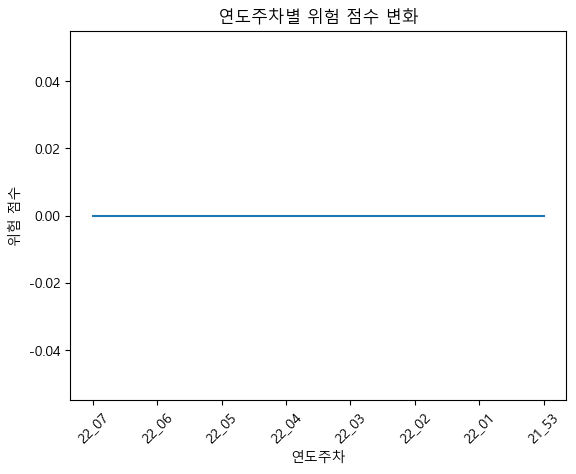

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-156.158, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-119.768, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-158.877, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-151.209, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-160.108, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-158.112, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-158.112, Time=0.06 sec
 ARIMA(1,0

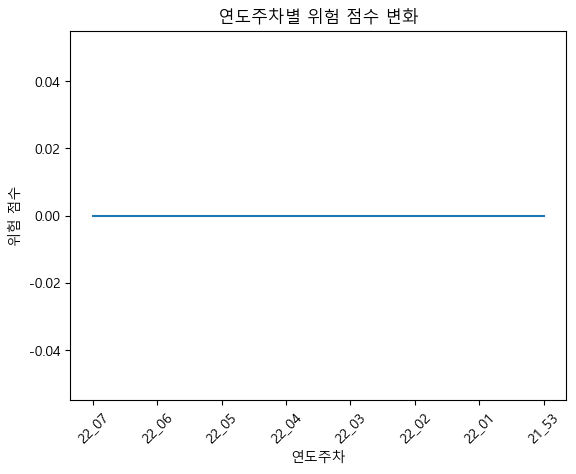

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
NaN 또는 0 값 포함 여부: False
22_16주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-142.552, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-110.297, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-145.197, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-139.176, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-145.285, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-143.788, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-144.526, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]           

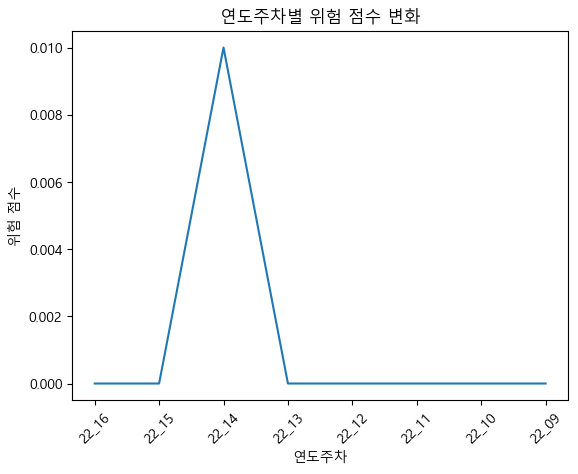

[np.float64(0.02), np.float64(1.58), np.float64(0.08), 0, 0, 0, 0, np.float64(0.01), np.float64(2.75), 0, np.float64(0.02), np.float64(4.83), 0, 0, np.float64(0.01)]
[56, 169, 84, 0, 0, 0, 0, 32, 34, 0, 36, 36, 0, 0, 24]


In [5]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
    df_price_4w = df_price_4w.bfill()
    contains_nan_or_zero = df_price_4w.isna().any().any() or (df_price_4w == 0).any().any()
    print(f"NaN 또는 0 값 포함 여부: {contains_nan_or_zero}")
    
    
    stl1 = STL(df_price_4w['단가'], period = 52, robust=False)
    res1 = stl1.fit()
    res_resid1 = res1.resid
    
    
    stl2 = STL(df_price_4w['신고중량'], period = 52, robust=False)
    res2 = stl2.fit()
    res_resid2 = res2.resid    

    contains_nan_or_zero = res_resid1.isna().any().any() or (res_resid1 == 0).any().any()
    print(f"NaN 또는 0 값 포함 여부: {contains_nan_or_zero}")

    contains_nan_or_zero = res_resid2.isna().any().any() or (res_resid2 == 0).any().any()
    print(f"NaN 또는 0 값 포함 여부: {contains_nan_or_zero}")


    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        res_resid = res_resid1.iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)
              
        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
        res_resid = res_resid2.iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]

        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)

        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
        
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y   
      
    if(z[j]>1.85):
        o[j] = 1
         
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model6(1)'] = o
collect.loc[15, 'Model6(1)'] = np.sum(o)
collect.loc[:14, 'Model6(2)'] = z
collect.loc[15, 'Model6(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[7]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[7]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[7]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=18.840, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=61.684, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=22.684, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=39.820, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=19.074, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=25.926, Time=0.04 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=18.317, Time=0.11 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=17.479, Time=0.06 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=16.013, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=27.795, Time=0.03 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=17.696, Time=0.06 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=19.144, Time=0.15 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=17.187, Time=0.06 sec

Best model:  ARIMA(0,0,3)(0,0,0)[0

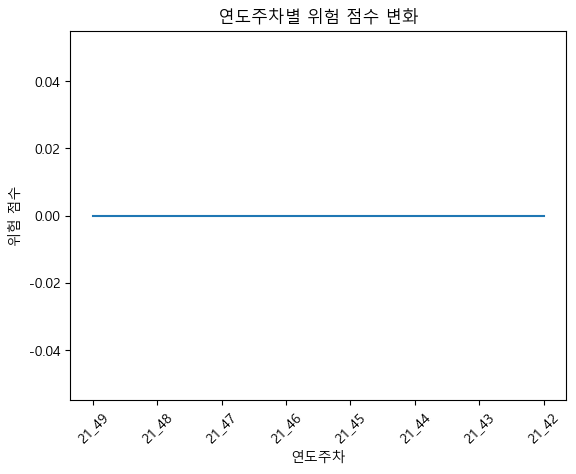

HS Code : 7326909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-83.537, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-58.813, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-88.193, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-83.461, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-87.087, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-86.951, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-85.900, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-86.204, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.189 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]

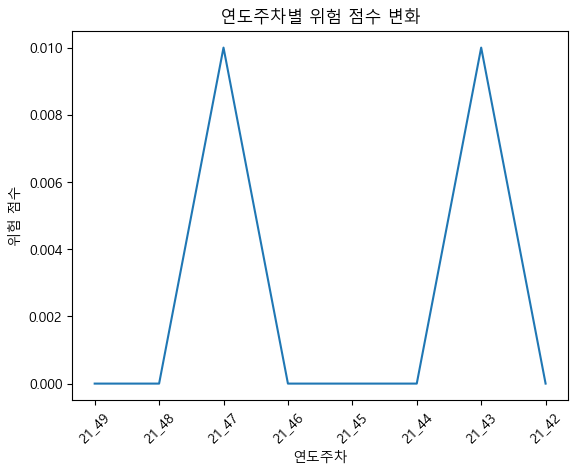

HS Code : 8708999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=20.767, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=64.770, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=17.745, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=38.039, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=19.611, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=19.652, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=21.396, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=19.697, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.127 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]        

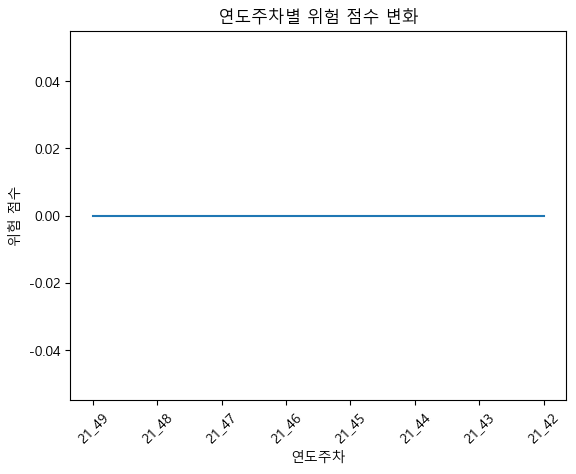

HS Code : 2106909099
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=142.125, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=163.917, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=148.227, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=150.391, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=146.268, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=148.742, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=144.106, Time=0.02 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=144.020, Time=0.03 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0]          
Total fit time: 0.537 seconds
====================== Sta

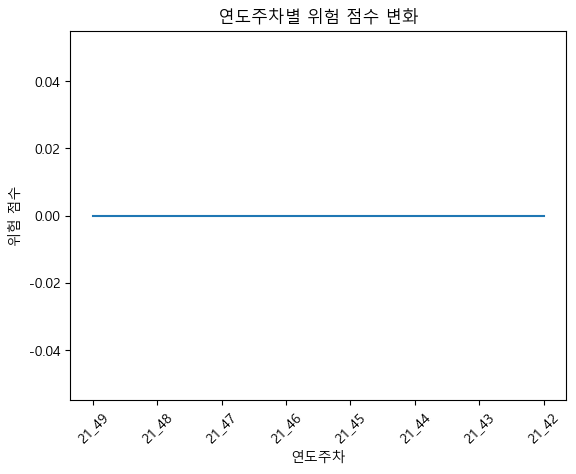

HS Code : 4911990000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=329.527, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=367.498, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=333.251, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=339.765, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=330.362, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=333.953, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=336.417, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=322.260, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=320.353, Time=0.02 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=318.605, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=340.773, Time=0.02 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=320.424, Time=0.03 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=322.262, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec

Best model:  ARIMA(0,

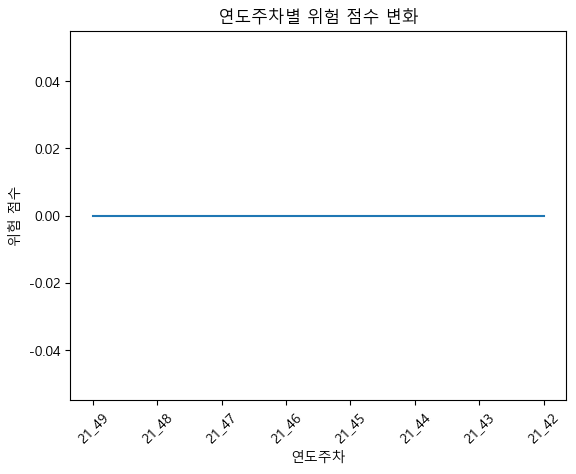

HS Code : 6403999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=190.752, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=233.920, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=194.439, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=189.881, Time=0.01 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=192.612, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=196.043, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=183.892, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=185.743, Time=0.12 sec

Best model:  ARIMA(1,0,3)(0,0,0)[0]      

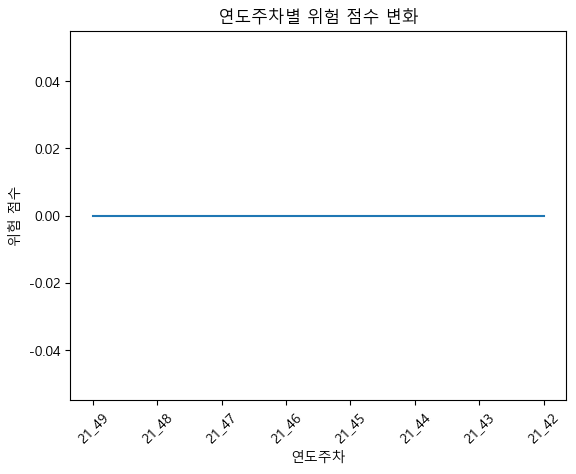

HS Code : 9031809099
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=390.564, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=436.182, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=392.747, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=401.314, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=391.972, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=388.989, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=390.981, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=389.375, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=390.731, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=389.363, Time=0.01 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=391.875, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=389.102, Time=0.02 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 0.205 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 

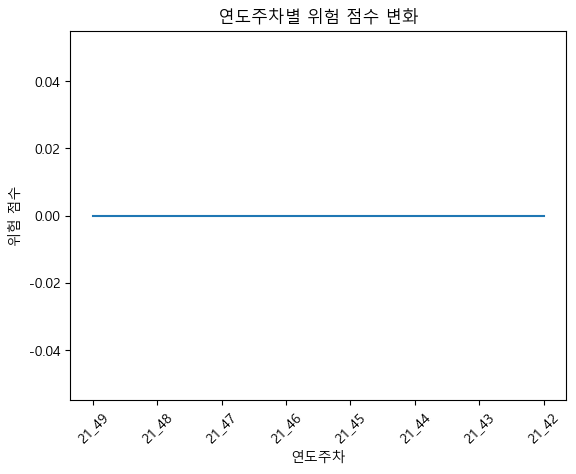

HS Code : 8542391000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=645.408, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=613.235, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=621.306, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=614.644, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=614.619, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=615.185, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.249 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]        

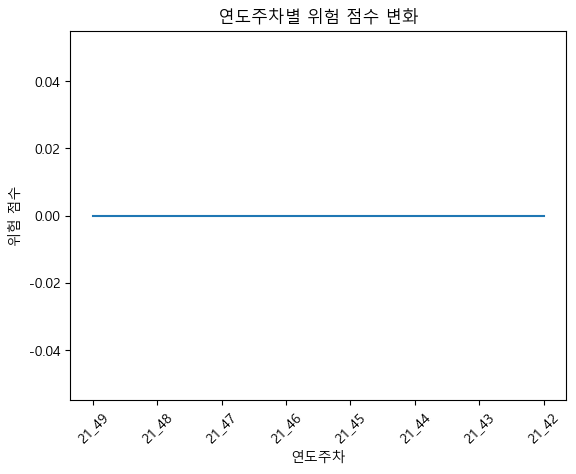

HS Code : 6109101000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=118.893, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=77.819, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=91.617, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=79.065, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=78.665, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=79.251, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.190 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             

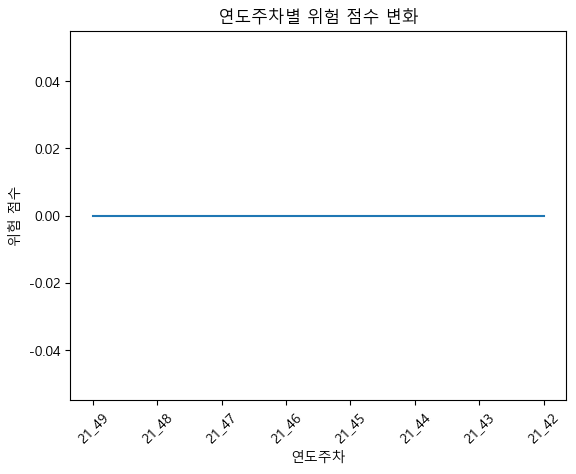

HS Code : 2934996000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=450.127, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=444.363, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=444.403, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=446.185, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=446.198, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=448.065, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=446.341, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.136 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1045.284, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0

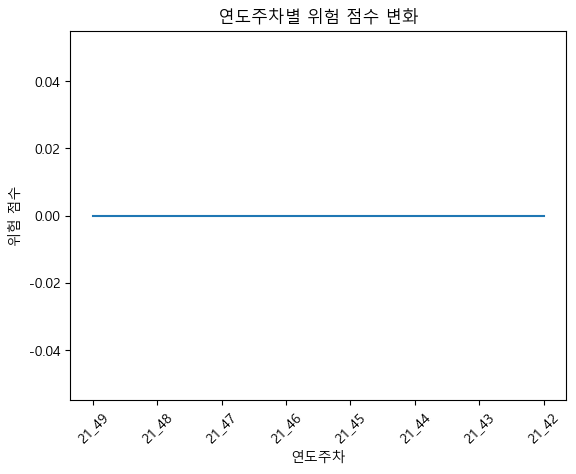

HS Code : 4016930000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=356.063, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=320.902, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=327.693, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=319.942, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=321.063, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=320.666, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=321.708, Time=0.02 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 0.240 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performin

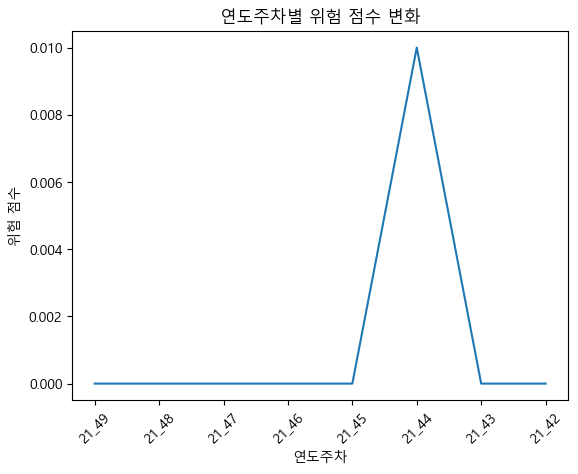

HS Code : 6110200000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=166.178, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=185.977, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=169.922, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=174.270, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=169.705, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=173.833, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=167.779, Time=0.05 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=171.911, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=164.969, Time=0.02 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=163.076, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=172.687, Time=0.01 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=164.910, Time=0.03 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=165.162, Time=0.06 sec
 ARIMA(0,0,3)(0,0,0)[0

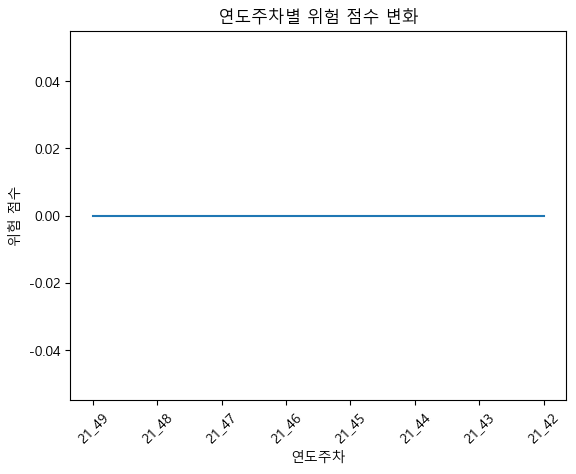

HS Code : 6211499000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=363.590, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=310.511, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=331.747, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=310.287, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=312.273, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=312.284, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=310.745, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=310.414, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=311.283, Time=0.01 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 0.189 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
P

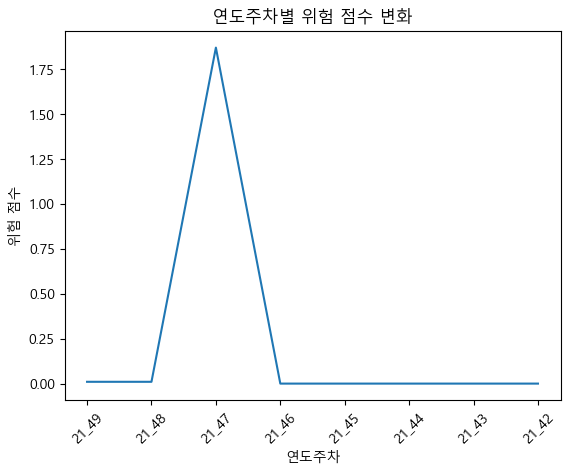

HS Code : 4202999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=254.631, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=284.599, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=257.866, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=254.555, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=253.669, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=252.677, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=252.498, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=253.821, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=254.664, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=254.487, Time=0.01 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 0.119 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ===========

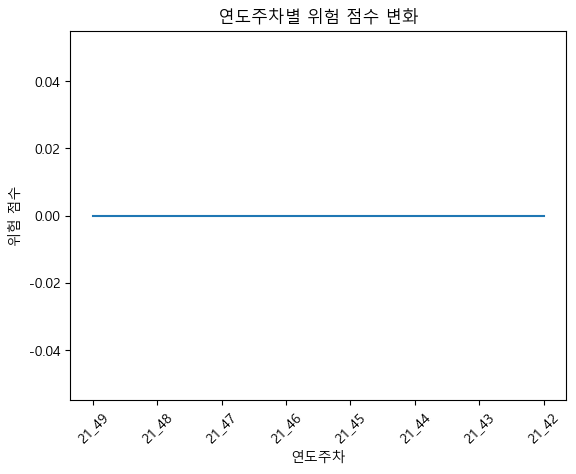

HS Code : 3304991000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=284.457, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=320.271, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=291.820, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=303.357, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=283.888, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=293.586, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=279.989, Time=0.04 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=281.578, Time=0.04 sec

Best model:  ARIMA(0,0,3)(0,0,0)[0]          
Total fit time: 0.529 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ============

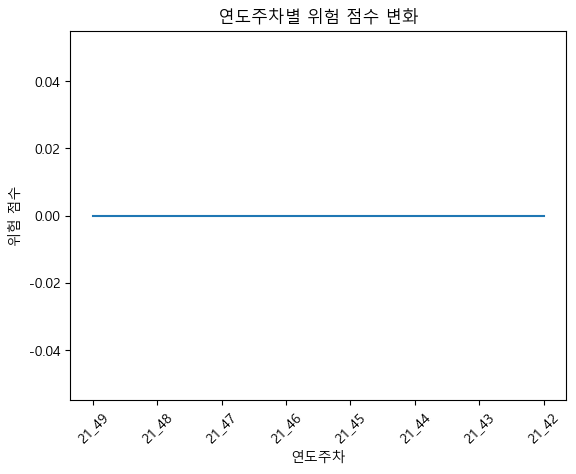

HS Code : 8544429090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=177.847, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=200.040, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=177.426, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=180.084, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=175.949, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=177.470, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=177.680, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=177.003, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=179.403, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=177.928, Time=0.01 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 0.116 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ===========

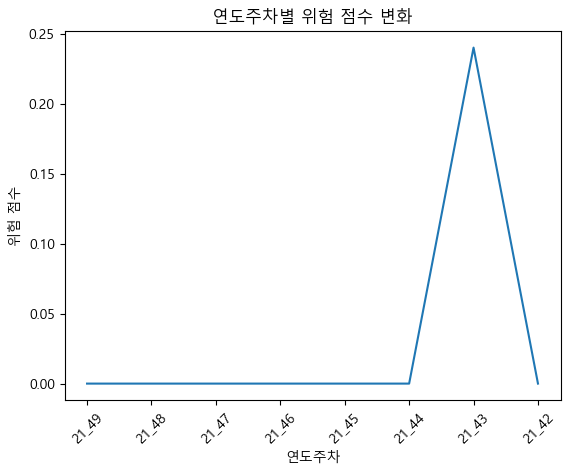

HS Code : 8481801090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=163.404, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=188.993, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=165.211, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=172.960, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=162.005, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=162.984, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=166.885, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=168.542, Time=0.02 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=163.643, Time=0.04 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 0.353 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ========

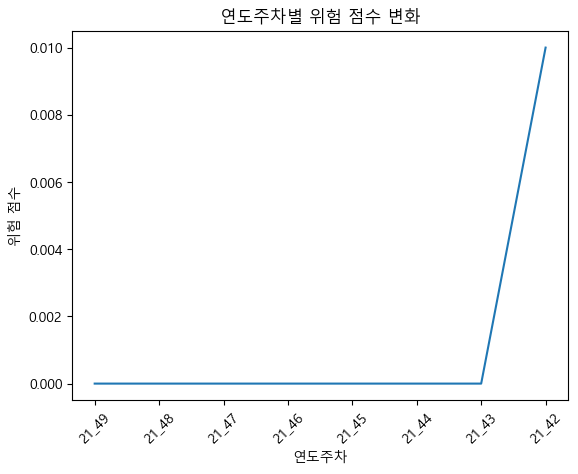

HS Code : 3304999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=314.204, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=348.729, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=314.947, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=321.892, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=317.630, Time=0.01 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=295.334, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=309.479, Time=0.03 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=297.577, Time=0.03 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec

Best model:  ARIMA(3,0,2)(0,0,0)[0]      

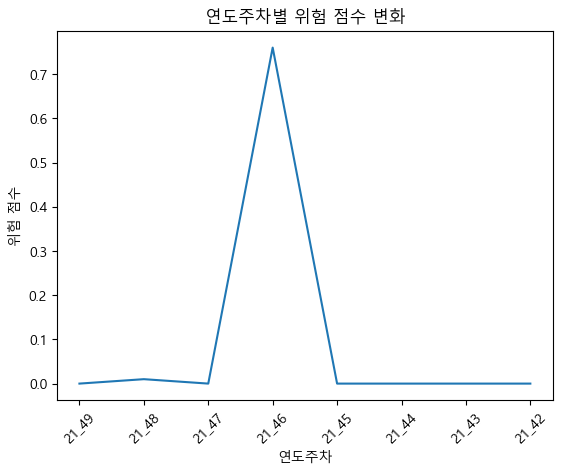

HS Code : 8543709090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=380.673, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=434.840, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=400.993, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=393.355, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=385.536, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=378.648, Time=0.06 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=380.627, Time=0.08 sec

Best model:  ARIMA(2,0,3)(0,0,0)[0]          

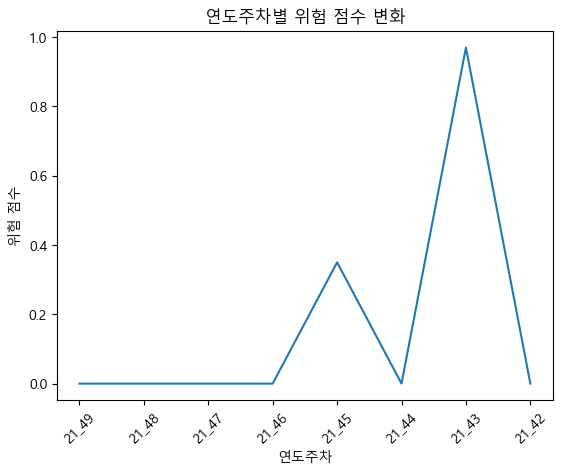

HS Code : 6404199000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=67.862, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=149.317, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=70.292, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=106.833, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=70.656, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=65.939, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=70.058, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=69.095, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=67.849, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=68.651, Time=0.01 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=68.929, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 0.356 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 =========

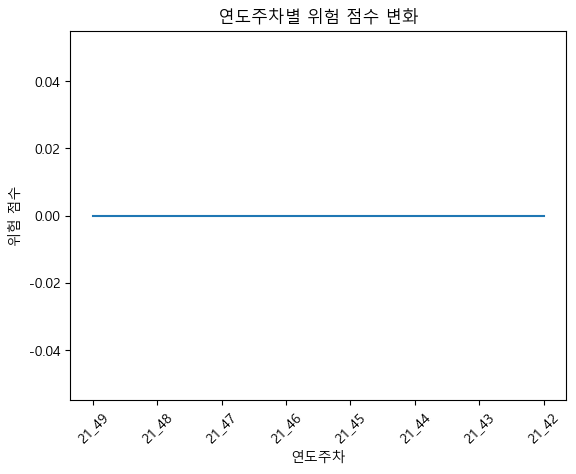

HS Code : 3004909900
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=347.178, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=401.560, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=352.610, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=357.160, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=348.576, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=349.439, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=334.012, Time=0.06 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=332.545, Time=0.04 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=335.947, Time=0.03 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=353.252, Time=0.02 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept 

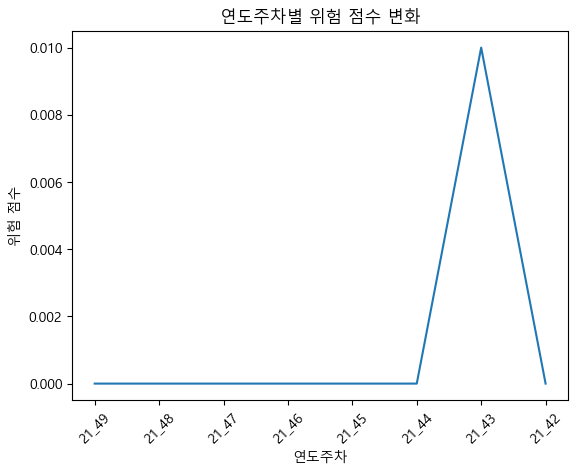

HS Code : 8542311000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=697.206, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=750.755, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=694.098, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=714.777, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=696.060, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=696.063, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=695.778, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=696.098, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.145 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]

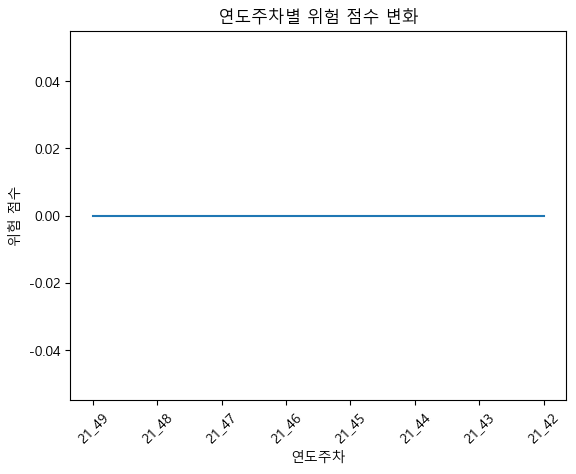

HS Code : 4901999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=142.118, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=129.377, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=128.989, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=131.368, Time=0.01 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=129.627, Time=0.01 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0]          
Total fit time: 0.207 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1072.384, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]       

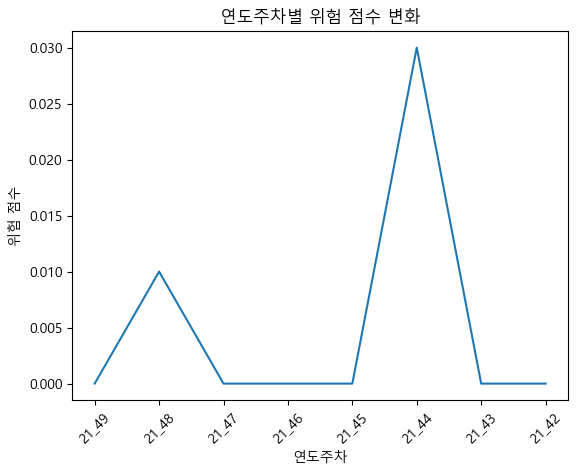

HS Code : 8473309090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=378.412, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=433.522, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=379.120, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=396.833, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=381.490, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=380.105, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=378.547, Time=0.03 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0]          
Total fit time: 0.582 seconds
====================== Statemo

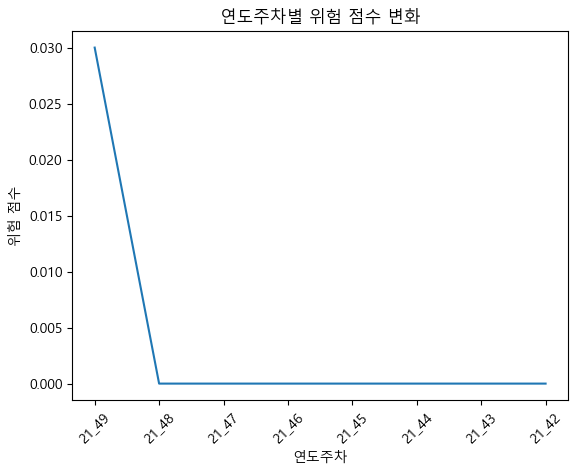

HS Code : 6307909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=50.784, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=202.103, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=83.655, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=55.325, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=51.671, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=49.940, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=52.846, Time=0.05 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=49.228, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=47.294, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=45.363, Time=0.03 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=78.920, Time=0.03 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=47.304, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             :

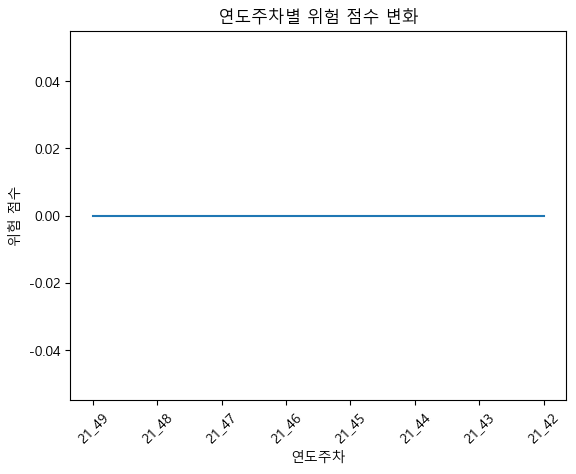

HS Code : 4202211090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=472.654, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=526.783, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=480.917, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=489.626, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=478.369, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=472.116, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=477.628, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=474.535, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=473.655, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=472.788, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 0.283 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ====

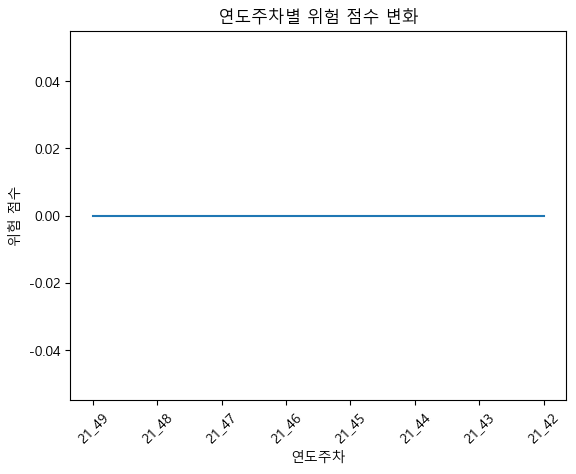

HS Code : 8536509090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=328.697, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=282.371, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=282.651, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=283.194, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=283.965, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.162 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=950.045, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]        

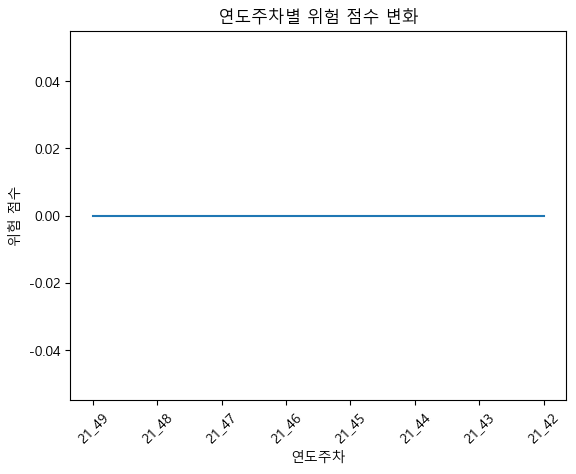

HS Code : 8538909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=199.104, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=265.471, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=194.554, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=226.279, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=196.286, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=196.344, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=197.585, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=196.325, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.098 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1088.615, Time=0.02 sec
 ARIMA(0,0,0)(0,0,

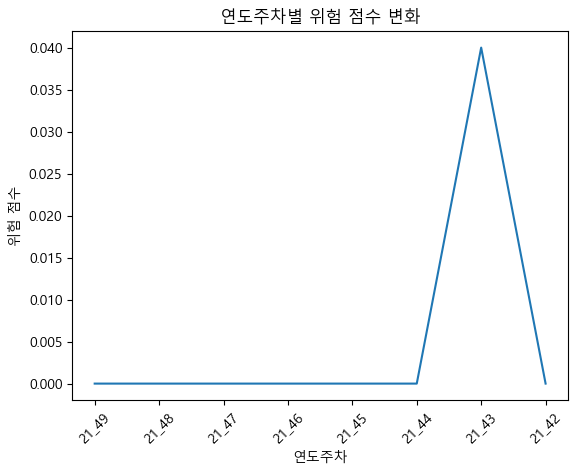

HS Code : 8479909090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=340.178, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=406.878, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=351.606, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=367.350, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=343.566, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=338.419, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=347.061, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=342.244, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=340.123, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=339.056, Time=0.01 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=342.122, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=338.648, Time=0.02 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 0.185 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 

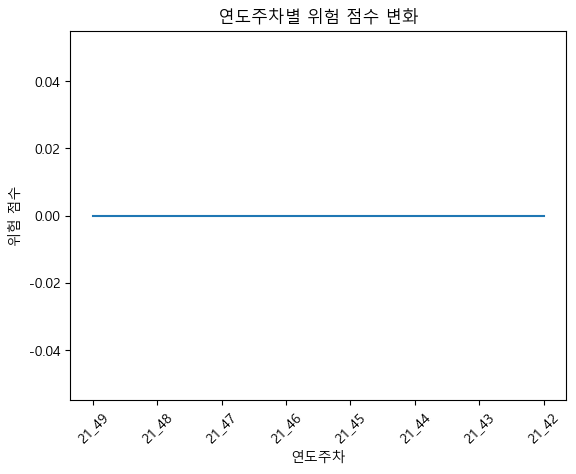

HS Code : 8504409099
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=240.223, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=283.183, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=236.221, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=251.990, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=237.710, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=237.835, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=237.735, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.112 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1078.653, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0

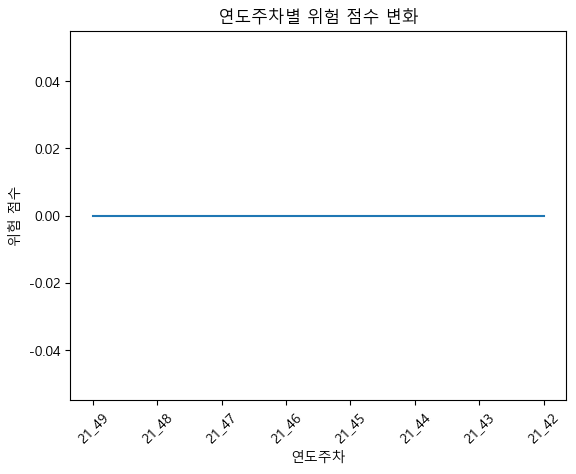

HS Code : 6110909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=394.399, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=434.974, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=390.924, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=405.487, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=392.574, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=392.658, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=392.890, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.118 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=824.502, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]

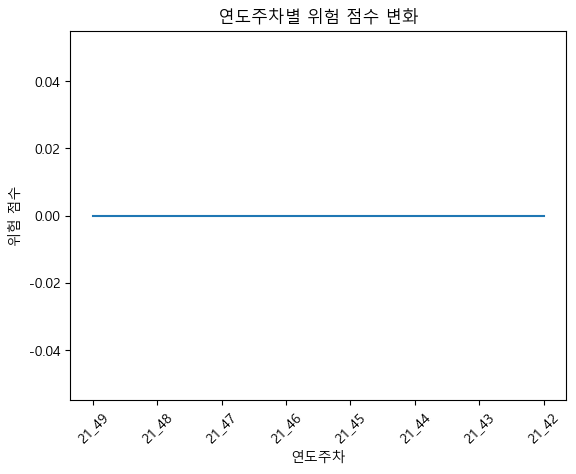

HS Code : 3923100000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-122.595, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-44.413, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-114.389, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-82.702, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-123.103, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-98.887, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-112.740, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-125.199, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-125.160, Time=0.10 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=-123.545, Time=0.11 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-124.419, Time=0.08 sec

Best model:  ARIMA(1,

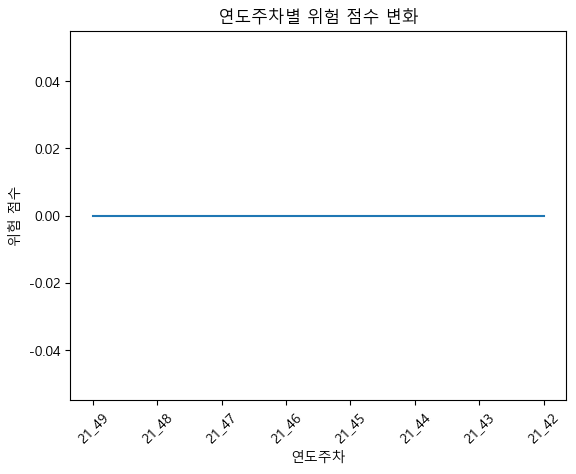

HS Code : 8544422090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=47.560, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=67.017, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=45.330, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=49.729, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=46.573, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=46.472, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=48.452, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=45.437, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.119 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1159.298, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]   

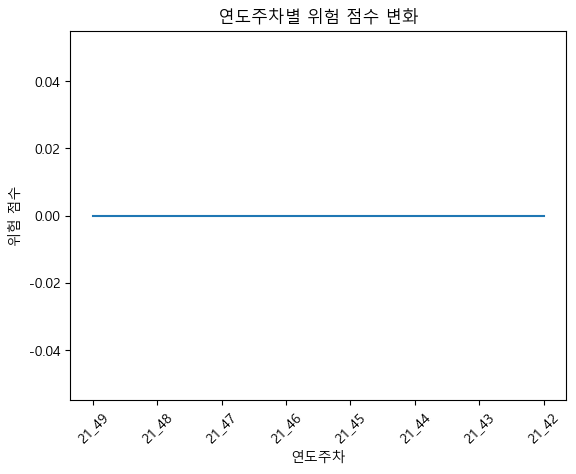

HS Code : 8537109000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=487.868, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=531.184, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=493.409, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=499.394, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=491.219, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=479.977, Time=0.09 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=477.992, Time=0.03 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=476.055, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=500.493, Time=0.02 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=477.995, Time=0.09 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=478.050, Time=0.10 sec

Best model:  ARIMA(0,0,3)(0,0

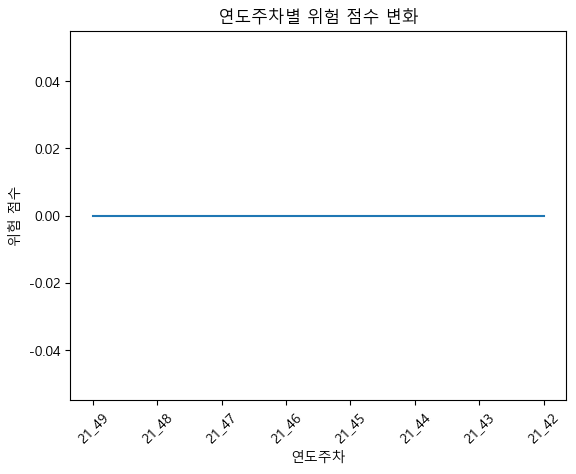

HS Code : 8536699000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=212.149, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=194.661, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=196.155, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=196.661, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=196.661, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=196.028, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.156 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1053.635, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]   

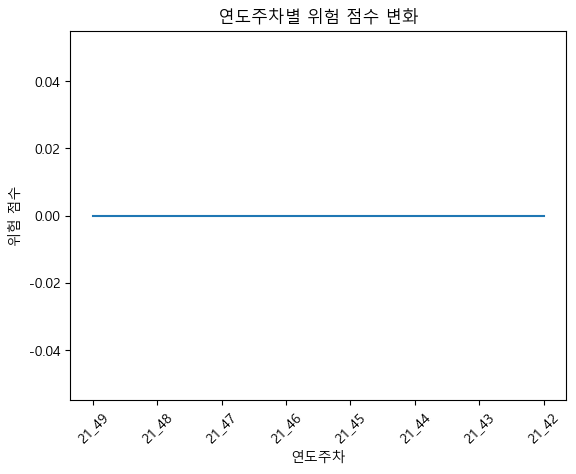

HS Code : 3102109000
21_14주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-303.443, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-295.113, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-305.292, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-301.325, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-297.020, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-305.697, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-303.826, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-303.657, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-305.285, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-302.003, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-307.701, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-307.254, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-305.816, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-305.648, Time=0.02 sec
 ARI

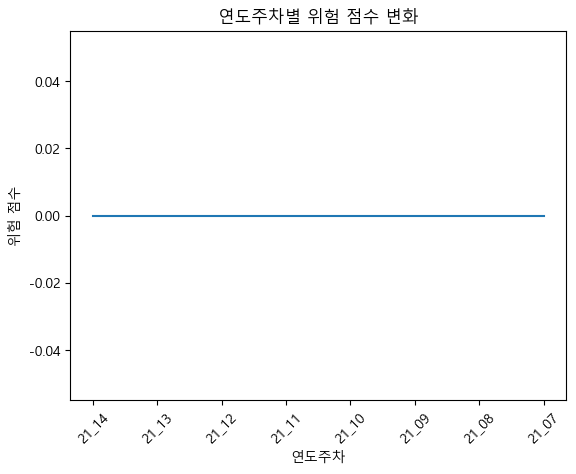

HS Code : 3707901010
19_04주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=448.206, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=423.056, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=430.366, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=424.280, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=424.693, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=423.177, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=425.027, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.158 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=912.904, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]

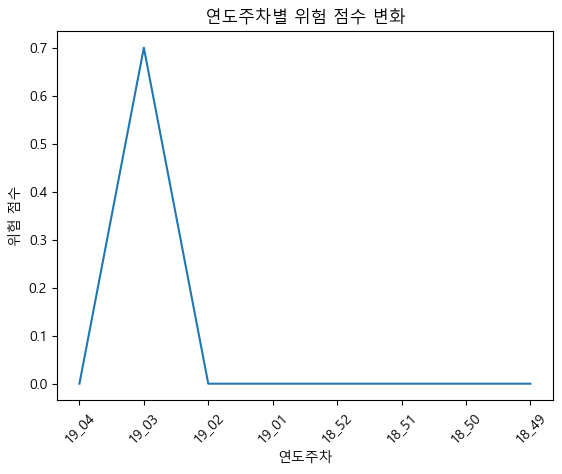

HS Code : 4407191000
20_41주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-189.070, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-157.450, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-188.540, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-186.828, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-186.058, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-190.587, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-187.118, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-187.246, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-183.246, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-186.196, Time=0.03 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-189.263, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-189.206, Time=0.07 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 0.485 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confiden

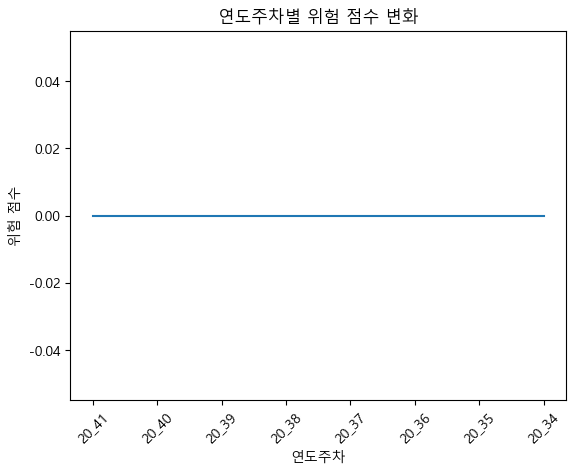

HS Code : 8111000000
21_19주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-123.624, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-111.659, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-127.060, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-120.300, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-112.289, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-127.595, Time=0.02 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-125.597, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-125.597, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-127.271, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-123.601, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-129.561, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-128.886, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-127.565, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-127.564, Time=0.02 sec
 ARI

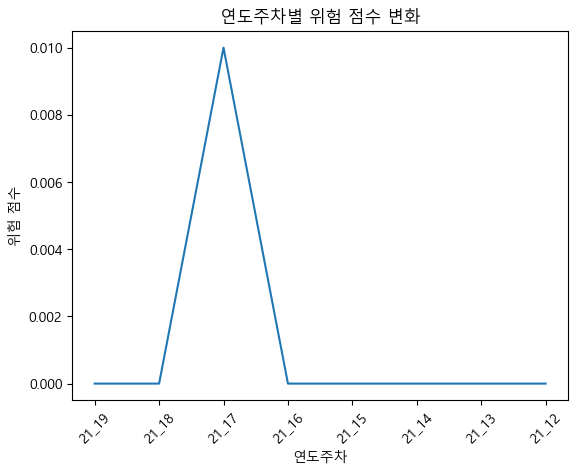

HS Code : 2701129010
21_25주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-350.397, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-341.659, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-346.925, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-344.627, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-343.013, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-350.813, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-352.858, Time=0.08 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-350.779, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-345.076, Time=0.04 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-348.888, Time=0.12 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-354.681, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-346.217, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-352.670, Time=0.08 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-352.695, Time=0.08 sec
 ARI

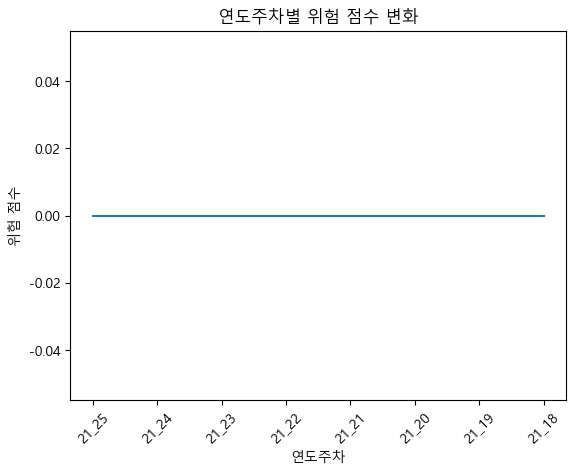

HS Code : 2804701000
21_25주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-64.221, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-58.163, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-59.765, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-58.885, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-59.587, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-62.177, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-57.018, Time=0.04 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-61.009, Time=0.11 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-66.175, Time=0.13 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-67.592, Time=0.09 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-65.226, Time=0.05 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=-67.847, Time=0.13 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=-67.293, Time=0.09 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(1,1,5)(0,0,0)[0

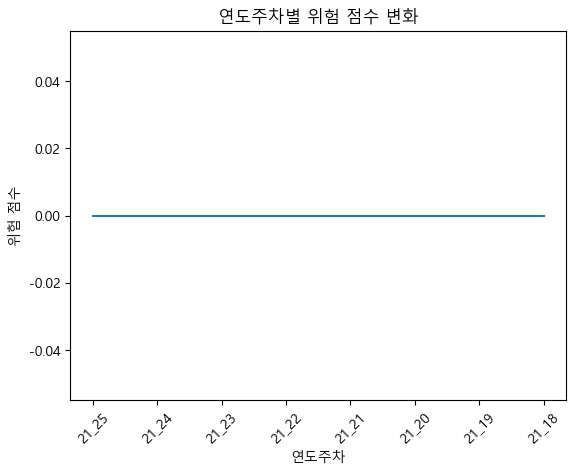

HS Code : 1511901000
21_29주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-230.379, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-234.790, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-233.540, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-233.694, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-235.965, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.235 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1411.991, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1426.810, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1417.486, Time=0.00 sec
 ARIMA(0,0,1)(0

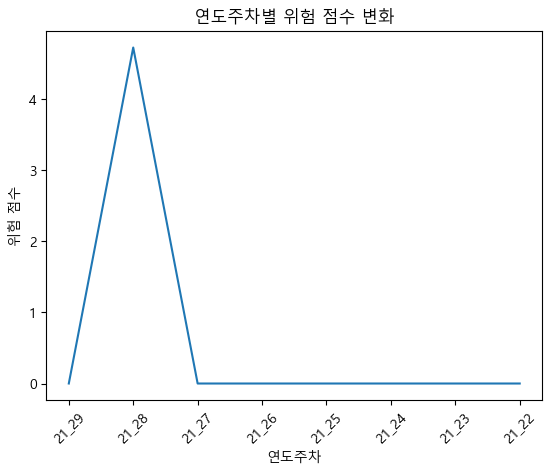

HS Code : 305531000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-6.977, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=37.280, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-7.703, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2.743, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-5.971, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-5.929, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-5.831, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.186 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1094.338, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]        

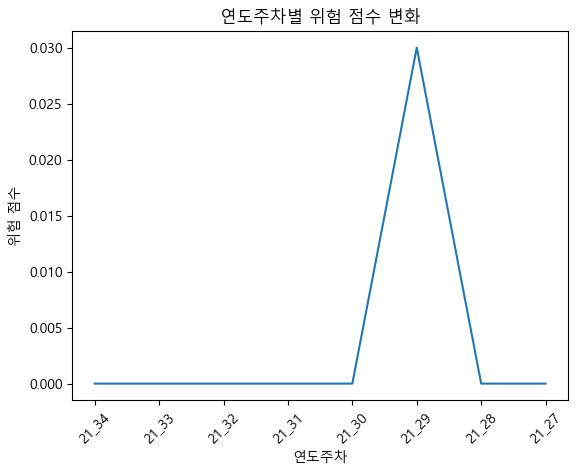

HS Code : 302140000
21_35주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-53.109, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=103.758, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-25.619, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-52.254, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-54.027, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-53.313, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-54.278, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-53.599, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-55.369, Time=0.05 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-53.569, Time=0.10 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-53.442, Time=0.08 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-51.599, Time=0.06 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=-52.508, Time=0.12 sec
 ARIMA(3,0,1)(0,0,0)[0]

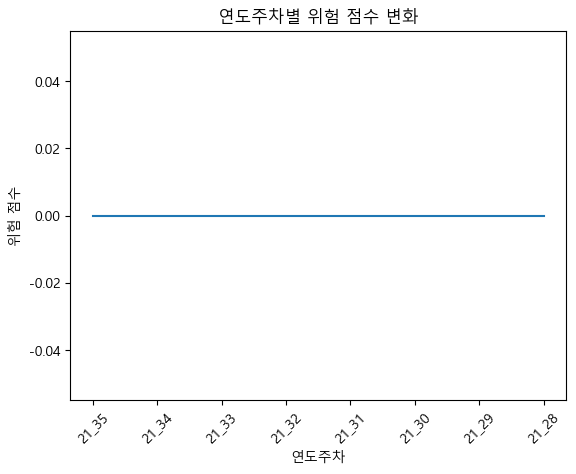

HS Code : 1003901000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-224.353, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-231.894, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-230.287, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-230.265, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-233.528, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-228.276, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.160 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1436.452, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1464.712, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1434.228, Time=0.00 sec
 ARIMA(0,0

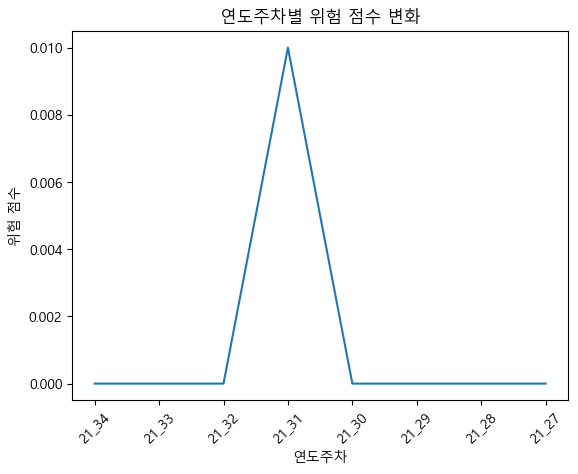

HS Code : 1003902000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-310.870, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-259.257, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-309.919, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-299.793, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-309.067, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-308.892, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-310.636, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-308.518, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-312.317, Time=0.08 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=-310.667, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-301.296, Time=0.04 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=-310.114, Time=0.08 sec
 ARIMA(2,0,4)(

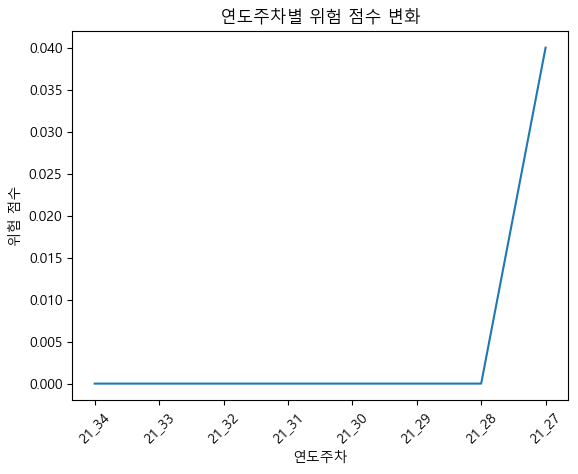

HS Code : 1104230000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=142.085, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=131.934, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=124.863, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=126.863, Time=0.01 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=126.863, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=126.772, Time=0.01 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0]          
Total fit time: 0.176 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1301.119, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]   

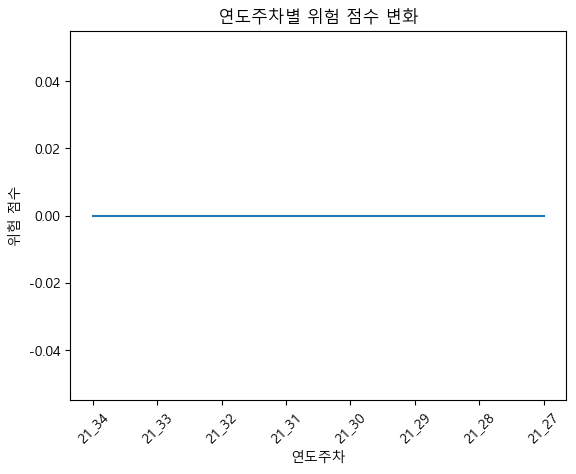

HS Code : 2710121000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=112.144, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=130.835, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=112.064, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=117.661, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=113.389, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=113.723, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=114.043, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.126 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]    

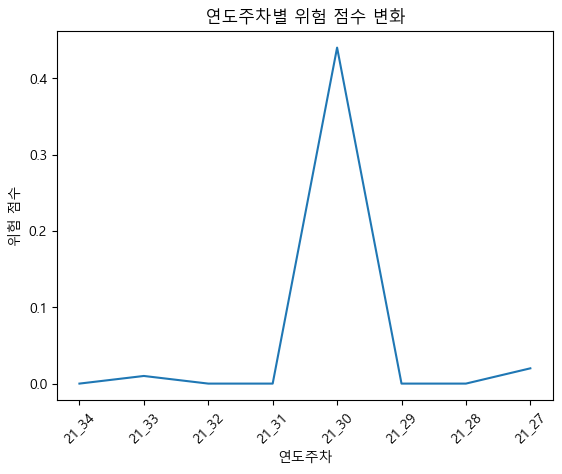

HS Code : 3104200000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-164.826, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-138.011, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-170.028, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-160.341, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-168.060, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-168.072, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-166.788, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-172.952, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-154.980, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-171.091, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-171.104, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-170.159, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-169.391, Time=0.08 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.381 s

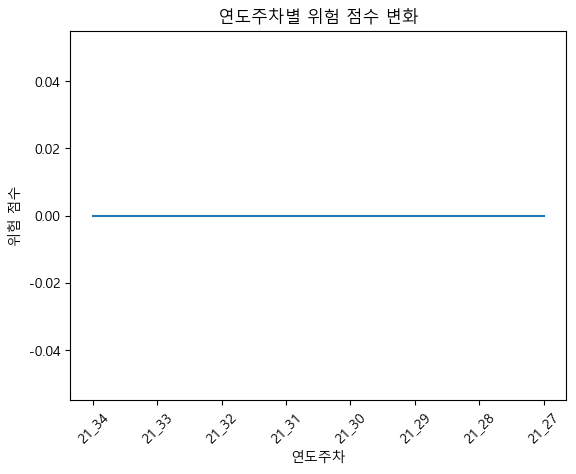

HS Code : 2905172000
21_43주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-87.830, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-131.285, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-120.957, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-130.084, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-130.005, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-128.469, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-130.297, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.188 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1126.992, Time=0.03 sec
 ARIMA(0,0,0)(0,

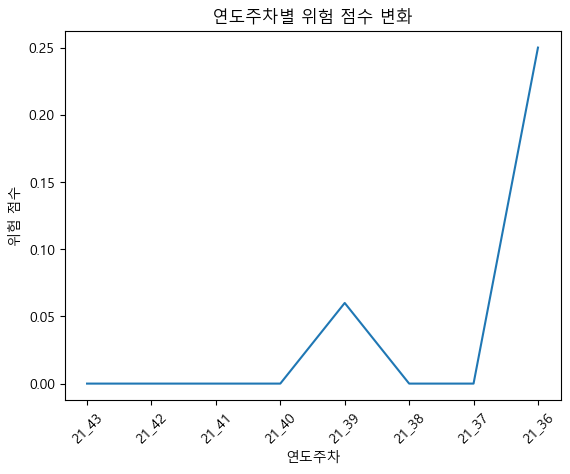

[0, np.float64(0.01), 0, 0, 0, 0, 0, 0, 0, 0, np.float64(0.01), 0, np.float64(1.87), 0, 0, np.float64(0.24), np.float64(0.01), np.float64(0.76), np.float64(0.97), 0, np.float64(0.01), 0, np.float64(0.03), np.float64(0.03), 0, 0, 0, np.float64(0.04), 0, 0, 0, 0, 0, 0, 0, 0, np.float64(0.7), 0, np.float64(0.01), 0, 0, np.float64(4.73), np.float64(0.03), 0, np.float64(0.01), np.float64(0.04), 0, np.float64(0.44), 0, np.float64(0.25)]
[0, 44, 0, 0, 0, 0, 0, 0, 0, 0, 47, 0, 44, 0, 0, 48, 49, 45, 48, 0, 48, 0, 47, 42, 0, 0, 0, 48, 0, 0, 0, 0, 0, 0, 0, 0, 193, 0, 74, 0, 0, 63, 62, 0, 60, 64, 0, 61, 0, 55]


In [7]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    df_price_4w = df_price_4w.bfill().ffill()
    stl1 = STL(df_price_4w['단가'], period = 52, robust=False)
    res1 = stl1.fit()
    res_resid1 = res1.resid
    
    stl2 = STL(df_price_4w['신고중량'], period = 52, robust=False)
    res2 = stl2.fit()
    res_resid2 = res2.resid    

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        res_resid = res_resid1.iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)
              
        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
        res_resid = res_resid2.iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]

        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)

        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]<1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model6(1)'] = o
collect.loc[50, 'Model6(1)'] = np.sum(o)
collect.loc[:49, 'Model6(2)'] = z
collect.loc[50, 'Model6(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[7]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[7]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[7]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)